<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Advanced Time Series: VAR Models
_Authors:_ Tim Book, Matt Brems, Noelle Brown (the dynamic trio)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import adfuller

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

We'll be using [U.S. Macroeconomic data](https://www.statsmodels.org/0.6.1/datasets/generated/macrodata.html) that is available via the `statsmodels` package. This is quarter-level data from 1959 to 2009.
- `year`: the year the data was measured.
- `quarter`: the quarter the data was measured.
- `realgdp`: real gross domestic product (in billions, in 2005 US dollars).
- `pop`: total population measured at the end of the quarter (includes all ages and overseas armed forces members).
- `unemp`: seasonally adjusted unemployment rate (in percent).

In [2]:
df = sm.datasets.macrodata.load_pandas().data
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [3]:
# Let's create a timeseries index from year and quarter
from statsmodels.tsa.base.datetools import dates_from_str

qtr = df['year'].astype(int).astype(str) + 'Q' + df['quarter'].astype(int).astype(str)
df.index = pd.to_datetime(dates_from_str(qtr))

df.drop(columns=['year', 'quarter'], inplace=True)

In [4]:
df.head()

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


# Topic 1: Generalized Least Squares
The main problem with OLS for time series data is that our "I" assumpiton (independence) is violated by definition - one data point directly depends on the one before it! We can create a **generalized least squares** estimate that eschews the "I" assumptions as follows:

$$y_t = \mathbf{x}_t^T\beta + w_t$$

where $w_t$ is an $\text{ARIMA}(p, q)$ process _instead_ of the usual $N(0, \sigma)$ assumption.

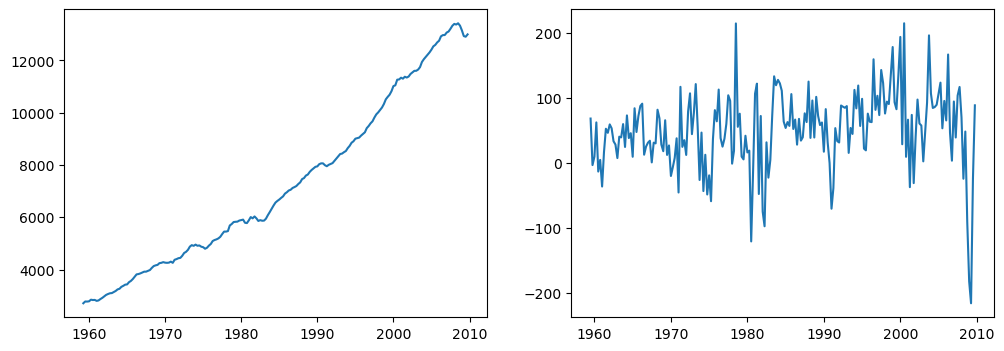

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(df.realgdp);
axs[1].plot(df.realgdp.diff());

In [6]:
y = df['realgdp']

xvars = ['realcons', 'realinv', 'realgovt', 'cpi', 'm1']
X = df[xvars]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=20)

In [7]:
gls = ARIMA(y_train, exog=X_train, order=(2, 1, 2), freq='Q-DEC').fit()

/Users/tim.book/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  self._init_dates(dates, freq)
/Users/tim.book/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/tim.book/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/tim.book/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [8]:
gls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                realgdp   No. Observations:                  183
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -775.039
Date:                Sun, 28 Jul 2024   AIC                           1570.078
Time:                        23:25:56   BIC                           1602.118
Sample:                    03-31-1959   HQIC                          1583.066
                         - 09-30-2004                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9811      0.043     22.569      0.000       0.896       1.066
realinv        1.0804      0.036     29.757      0.000       1.009       1.152
realgovt       0.7127      0.130      5.489      0.000       0.458       0.967
cpi           -0.3611      1.988     -0.182      0.856      -4.259       3.536
m1             0.1978      0.160      1.235      0.217      -0.116       0.512
ar.L1          1.8400      0.051     36.327      0.000       1.741       1.939
ar.L2         -0.9216      0.052    -17.659      0.000      -1.024      -0.819
ma.L1         -1.8039      0.049    -36.797      0.000      -1.900      -1.708
ma.L2          0.9402      0.046     20.433      0.000       0.850       1.030
sigma2       295.9635     28.663     10.326      0.000     239.785     352.142
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                24.93
Prob(Q):                              0.77   Prob(JB):                         0.00
Heteroskedasticity (H):               3.87   Skew:                             0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
preds = gls.predict(start=X_test.index[0], end=X_test.index[-1], exog=X_test)

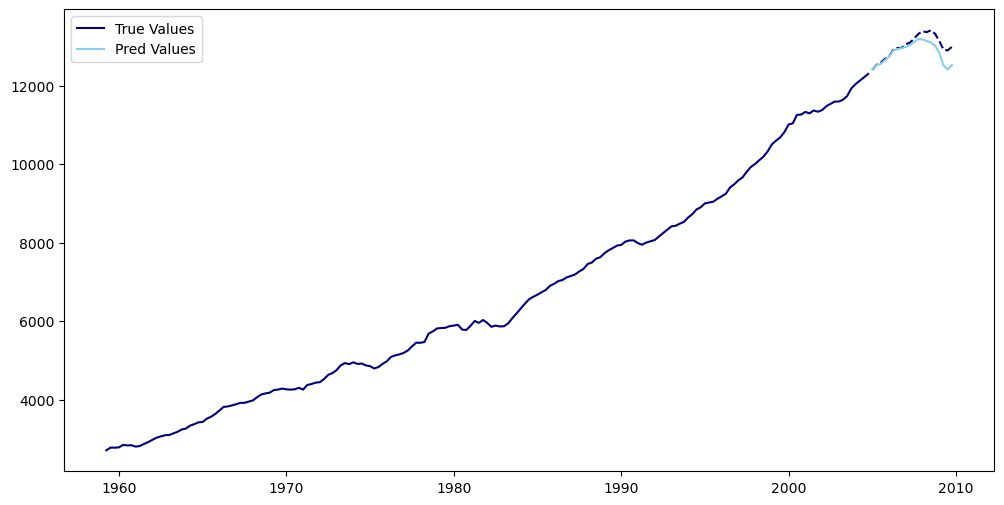

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, c='navy', label='True Values')
plt.plot(y_test, c='navy', linestyle='dashed')
plt.plot(preds, c='skyblue', label='Pred Values')
plt.legend();

# Topic 2: GARCH Models

**Generalized autoregressive conditional heteroscedasticity (GARCH) models** can be used for time series data in which the series' variance changes over time and is susceptible to periods of large fluctuations. Because of this, it is particularly applicable to financial data.

In [11]:
# !pip install arch

import arch

In [12]:
# Try this if you want!
# !pip install yfinance
# import yfinance as yf
# mcd = yf.download('MCD')

mcd = pd.read_csv('data/dis.csv').set_index('Date')
mcd.index = pd.to_datetime(mcd.index)
mcd = mcd[mcd.index.year >= 2000]
mcd.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,28.855125,29.533344,28.361876,29.471687,22.934357,8402230
2000-01-04,29.594999,31.444689,29.594999,31.198063,24.277788,16051191
2000-01-05,31.198063,32.677814,31.198063,32.492844,25.285370,19823822
2000-01-06,32.492844,32.677814,31.198063,31.198063,24.277788,7903193
2000-01-07,31.198063,31.691313,30.396530,30.704813,23.893953,6773543


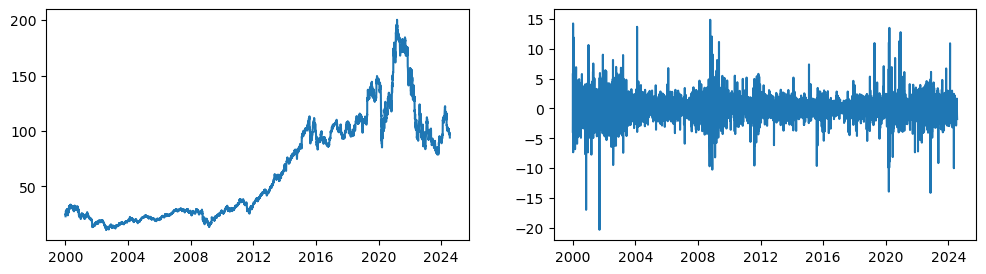

In [13]:
# plt.plot(dis['Adj Close']);
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

# The GARCH model will ask us to increase the scale of Z for
# algorithmic efficiency.
z = 100*np.log(mcd['Adj Close']).diff().dropna()
z_train, z_test = train_test_split(z, shuffle=False, test_size=0.05)

axs[0].plot(mcd['Adj Close'])
axs[1].plot(z);

In [14]:
from arch import arch_model

garch = arch_model(z_train, vol='Garch', p=2, q=2).fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 34182.38928947132
Iteration:      2,   Func. Count:     19,   Neg. LLF: 1508691.561282618
Iteration:      3,   Func. Count:     28,   Neg. LLF: 12675.21200148726
Iteration:      4,   Func. Count:     38,   Neg. LLF: 11317.105569739579
Iteration:      5,   Func. Count:     46,   Neg. LLF: 11320.547387040733
Iteration:      6,   Func. Count:     54,   Neg. LLF: 11273.023347710512
Iteration:      7,   Func. Count:     62,   Neg. LLF: 11331.004694414849
Iteration:      8,   Func. Count:     70,   Neg. LLF: 11251.103371396624
Iteration:      9,   Func. Count:     77,   Neg. LLF: 11311.441538536288
Iteration:     10,   Func. Count:     85,   Neg. LLF: 11248.749665813468
Iteration:     11,   Func. Count:     92,   Neg. LLF: 11248.51823656316
Iteration:     12,   Func. Count:     99,   Neg. LLF: 11248.283963682514
Iteration:     13,   Func. Count:    106,   Neg. LLF: 11248.279544614777
Iteration:     14,   Func. Count:    113,   Neg. LLF: 1

In [15]:
garch.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -11248.3
Distribution:                  Normal   AIC:                           22508.6
Method:            Maximum Likelihood   BIC:                           22548.6
                                        No. Observations:                 5866
Date:                Sun, Jul 28 2024   Df Residuals:                     5865
Time:                        23:25:57   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0486  1.999e-02      2.429  1.513e-02 [9.381e-03,8.774e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0867  3.430e-02      2.528  1.147e-02    [1.948e-02,  0.154]
alpha[1]       0.0950  2.531e-02      3.753  1.744e-04    [4.539e-02,  0.145]
alpha[2]       0.0513  1.791e-02      2.866  4.161e-03  [1.622e-02,8.645e-02]
beta[1]    2.1671e-16  4.243e-02  5.107e-15      1.000 [-8.317e-02,8.317e-02]
beta[2]        0.8349  4.293e-02     19.450  2.942e-84      [  0.751,  0.919]
=============================================================================

Covariance estimator: robust
"""

In [16]:
preds = garch.forecast(horizon=len(z_test), reindex=False)

In [17]:
# This is the future forecast - notice it's all the same number, and it's usually close to zero.
# The GARCH model makes simple predictions, and is more focuses on measuring the forecast volatility.
preds.mean

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.300,h.301,h.302,h.303,h.304,h.305,h.306,h.307,h.308,h.309
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-27,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,...,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856,0.04856


In [18]:
# This is the true prediction of the GARCH model - this measures the future volatility
# along our forecast horizon.
preds.variance

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.300,h.301,h.302,h.303,h.304,h.305,h.306,h.307,h.308,h.309
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-27,3.375588,2.821266,3.346351,2.904948,3.328388,2.977407,3.31935,3.040766,3.317358,3.09673,...,4.545188,4.545972,4.546748,4.547517,4.548278,4.549032,4.549778,4.550517,4.551249,4.551973


# Topic 3: VAR Models

We'll use the US economic data again.

In [19]:
df = sm.datasets.macrodata.load_pandas().data
qtr = df['year'].astype(int).astype(str) + 'Q' + df['quarter'].astype(int).astype(str)
df.index = pd.to_datetime(dates_from_str(qtr))
df.drop(columns=['year', 'quarter'], inplace=True)

In [20]:
df.head()

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [21]:
# We'll use unemployment, population, and GDP as our variables for prediction
df_var = df[['realgdp', 'pop', 'unemp']]

In [22]:
# It's easiest if we do the diffing ourselves.
# Let's eyeball each variable and decide how many diffs we need.
def plot_diff(v):
    fig, axs = plt.subplots(3, 1, figsize=(10, 6))
    axs[0].plot(v)
    axs[1].plot(v.diff())
    axs[2].plot(v.diff().diff())

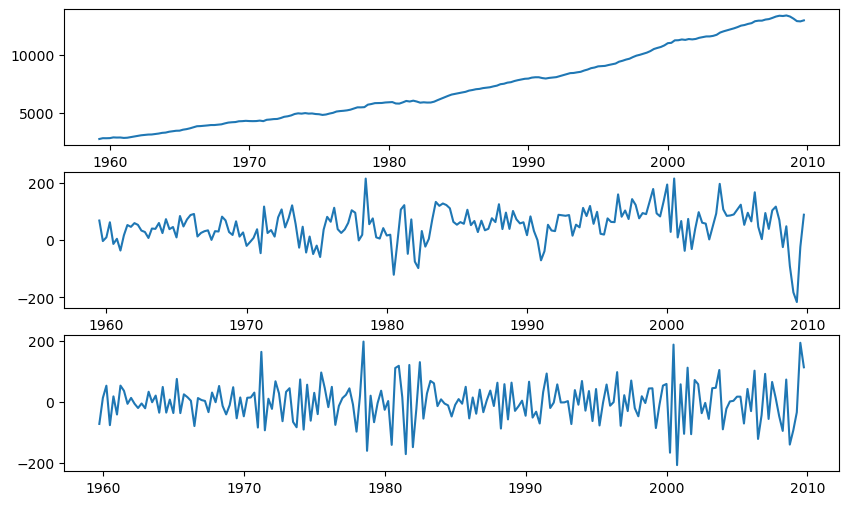

In [23]:
plot_diff(df_var['realgdp'])

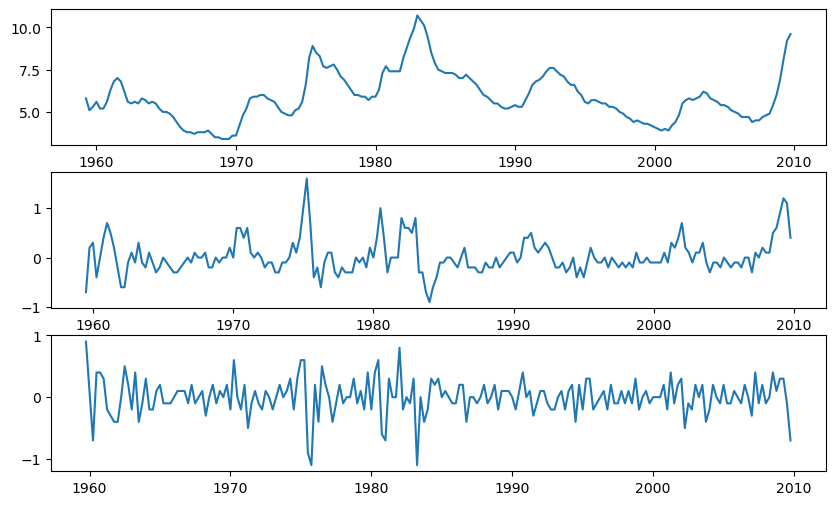

In [24]:
plot_diff(df_var['unemp'])

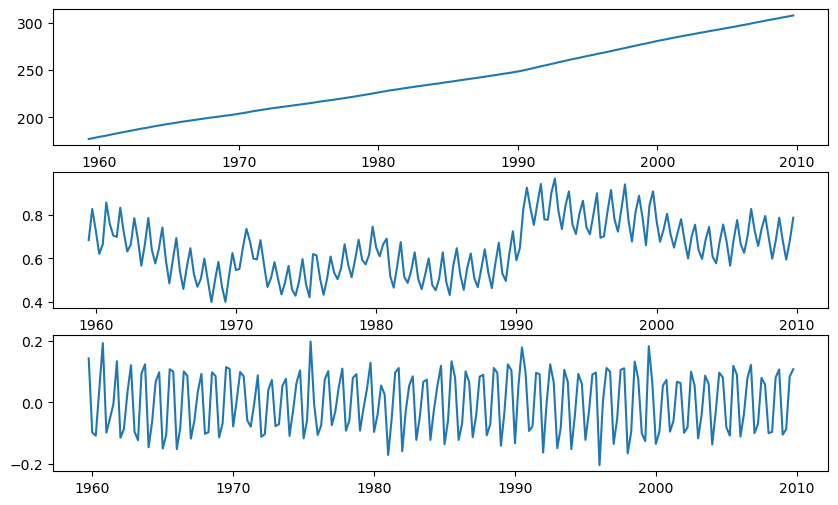

In [25]:
plot_diff(df_var['pop'])

In [26]:
# We'll use these diffs
df_var_diff = pd.DataFrame({
    'pop_d2': df_var['pop'].diff().diff(),
    'unemp_d1': df_var['unemp'].diff(),
    'realgdp_d1': df_var['realgdp'].diff()
})

df_var_diff.dropna(inplace=True)

In [27]:
df_var_diff.head()

,pop_d2,unemp_d1,realgdp_d1
1959-09-30,0.143,0.2,-3.313
1959-12-31,-0.098,0.3,9.716
1960-03-31,-0.108,-0.4,62.495
1960-06-30,0.043,0.0,-13.309
1960-09-30,0.193,0.4,4.632


In [28]:
from statsmodels.tsa.api import VAR

# We tell the VAR model to optimize based on AIC up to 15 lags
model = VAR(df_var_diff, freq='Q-DEC').fit(maxlags=15, ic='aic')

In [29]:
# Best model was found at p=9 lags!
model.k_ar

9

In [30]:
model.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 28, Jul, 2024
Time:                     23:25:58
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.160828
Nobs:                     192.000    HQIC:                  -1.00878
Log likelihood:          -581.054    FPE:                   0.206037
AIC:                     -1.58598    Det(Omega_mle):        0.136956
--------------------------------------------------------------------
Results for equation pop_d2
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.002408         0.007310            0.329           0.742
L1.pop_d2            -0.210700         0.078671           -2.678           0.007
L1.unemp_d1           0.025059         0.013476            

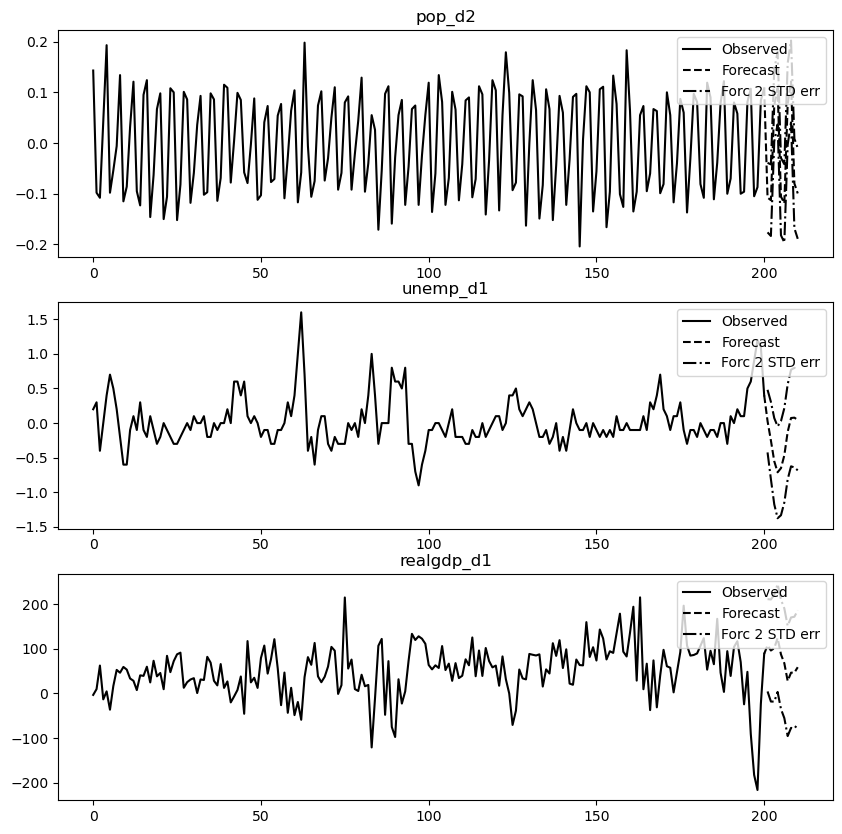

In [31]:
model.plot_forecast(10);